In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [38]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.shape

(48895, 16)

In [7]:
#EDA

Check for missing values

In [8]:
missing = df.isna().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


Target feature

In [9]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

Classification faces the problem: Class Imbalance, Bias

<Axes: xlabel='room_type', ylabel='count'>

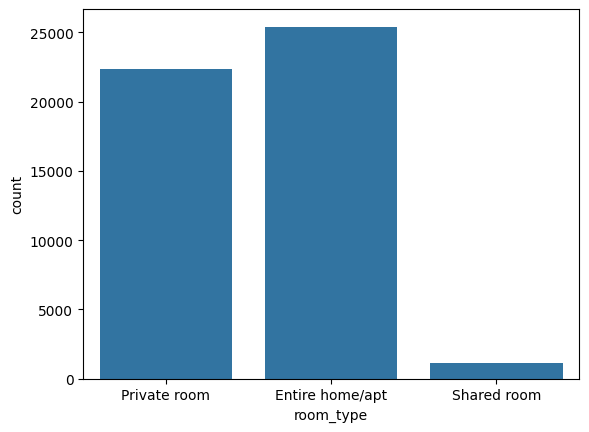

In [10]:
sns.countplot(x = df['room_type'])

Univariate analysis

In [11]:
numeric_cols = ['price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

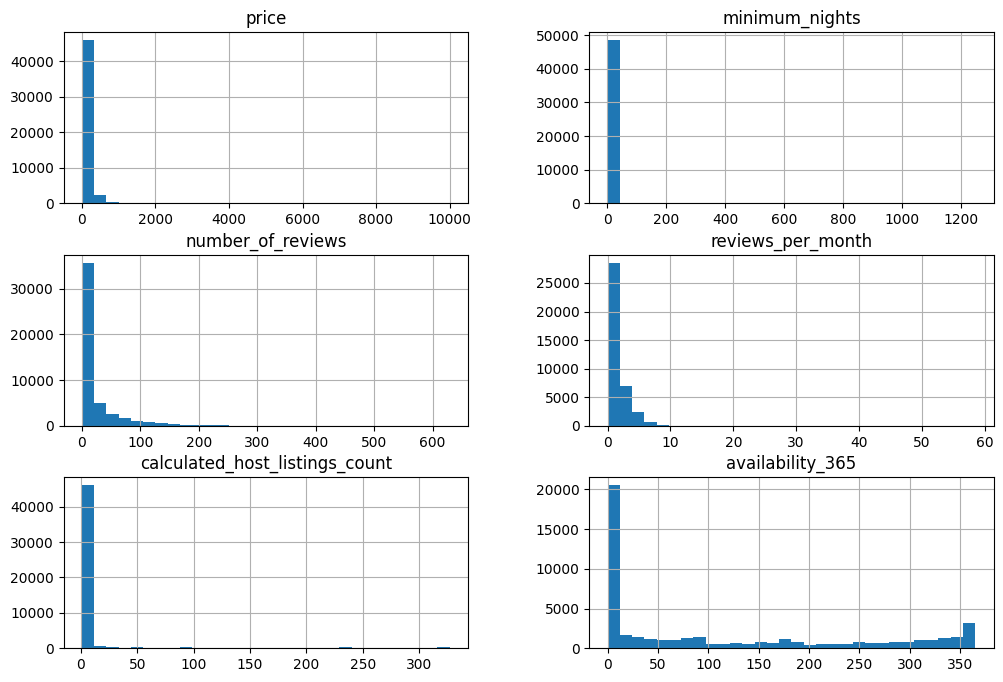

In [12]:
df[numeric_cols].hist (bins=30, figsize=(12, 8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

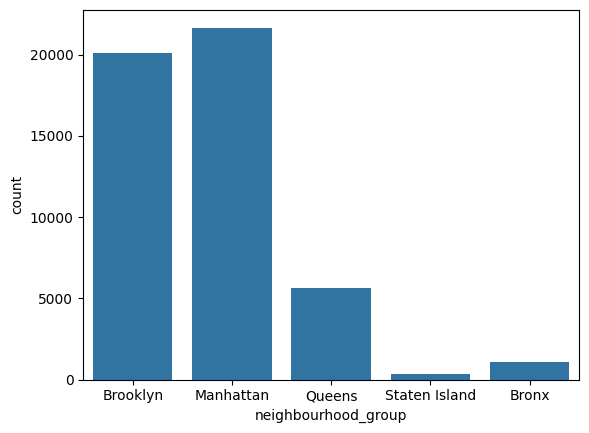

In [13]:
sns.countplot(x='neighbourhood_group', data=df)

Bivariate analysis

<Axes: xlabel='room_type', ylabel='price'>

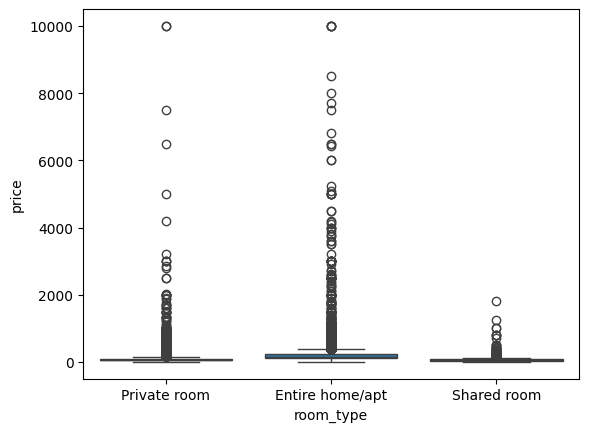

In [14]:
sns.boxplot(x='room_type', y='price', data=df)

In [15]:
corr = df[numeric_cols + ['longitude', 'latitude']].corr()

<Axes: >

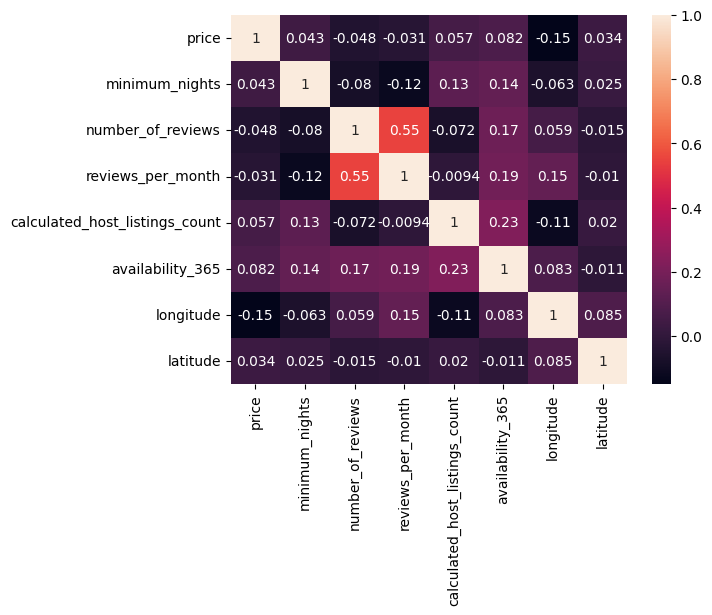

In [16]:
sns.heatmap(corr, annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

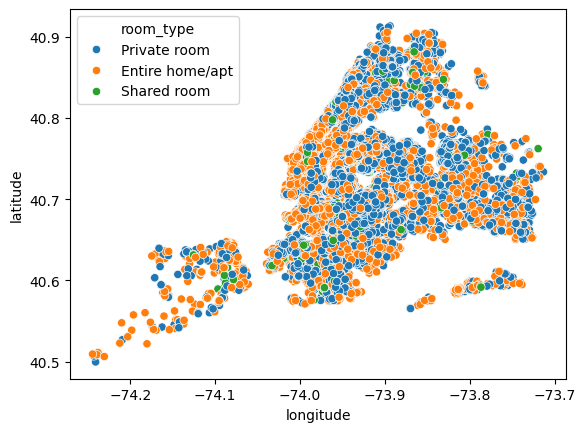

In [17]:
sns.scatterplot(x='longitude', y='latitude', data=df, hue='room_type')

Data Cleaning

In [18]:
df_clean = df.drop(columns=['id', 'name', 'host_id',	'host_name', 'last_review'])

In [19]:
df_clean['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_1724/2069112546.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['reviews_per_month'].fillna(0, inplace=True)


In [20]:
#Data clipping
price_cap = df_clean['price'].quantile(0.99)
night_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=night_cap)

In [21]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

Training Testing Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#stratify ensures that your train and test datasets keep the exact same proportion of target class labels as your original dataset.

Column Transfer + Pipeline

In [23]:
numeric_cols = df_clean.select_dtypes(include='number').columns
object_cols = ['neighbourhood_group', 'neighbourhood']
print(numeric_cols)

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [24]:
df_clean[numeric_cols].skew()

,0
latitude,0.237167
longitude,1.284210
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [25]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [26]:
#Pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='median')),
    #('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
object_pipeline = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [27]:
#=ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('numeric', numeric_pipeline, numeric_cols),
                                               ('object', object_pipeline, object_cols)])
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')),
                                ('object',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

class_weight='balanced', tells the model to pay more attention to the minority or rare class

In [29]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

Hyperparameter Tuning

In [30]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[('Preprocessing', preprocessor), ('Classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])

param_distribution = {
  "Classifier__n_estimators" : [100,200,150,300],
  "Classifier__max_depth": [8, 12, 15, 20, None],
  "Classifier__min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
  estimator=best_pipeline,
  param_distributions=param_distribution,
  n_iter=10,
  cv=3,
  scoring="f1_macro",
  random_state=42
)

In [31]:
search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('Preprocessing',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputation',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('Classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   param_distributions={'Classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'Classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'Classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [32]:
print("Best Parameters :", search.best_params_)
print("Best Score :", search.best_score_)

Best Parameters : {'Classifier__n_estimators': 200, 'Classifier__min_samples_split': 10, 'Classifier__max_depth': 20}
Best Score : 0.7345363574152045


In [33]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

In [34]:
import sklearn
print(sklearn.__version__)

1.6.1


In [35]:
df.head(1)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365


In [37]:
print(df['neighbourhood'].unique())


['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem'
 'Murray Hill' 'Bedford-Stuyvesant' "Hell's Kitchen" 'Upper West Side'
 'Chinatown' 'South Slope' 'West Village' 'Williamsburg' 'Fort Greene'
 'Chelsea' 'Crown Heights' 'Park Slope' 'Windsor Terrace' 'Inwood'
 'East Village' 'Greenpoint' 'Bushwick' 'Flatbush' 'Lower East Side'
 'Prospect-Lefferts Gardens' 'Long Island City' 'Kips Bay' 'SoHo'
 'Upper East Side' 'Prospect Heights' 'Washington Heights' 'Woodside'
 'Brooklyn Heights' 'Carroll Gardens' 'Gowanus' 'Flatlands' 'Cobble Hill'
 'Flushing' 'Boerum Hill' 'Sunnyside' 'DUMBO' 'St. George' 'Highbridge'
 'Financial District' 'Ridgewood' 'Morningside Heights' 'Jamaica'
 'Middle Village' 'NoHo' 'Ditmars Steinway' 'Flatiron District'
 'Roosevelt Island' 'Greenwich Village' 'Little Italy' 'East Flatbush'
 'Tompkinsville' 'Astoria' 'Clason Point' 'Eastchester' 'Kingsbridge'
 'Two Bridges' 'Queens Village' 'Rockaway Beach' 'Forest Hills' 'Nolita'
 'Woodlawn' 'University Heights' '